# 19 — `bounds_image`: per-pixel parameter bounds in lmfit superpixel inversion

Demonstrates the `bounds_image` API of `lmfit_engine`, `superpixel_engine`, and
`dask_engine`: spatially varying per-pixel parameter bounds derived from ancillary
information.

**Use case**: the 865 nm NIR band is used as a rough depth proxy — bright NIR
indicates a large bottom contribution (shallow water); dim NIR indicates deep water.
This proxy drives a per-pixel upper bound on `zB`, constraining the optimizer in
shallow tidal areas and preventing spuriously deep solutions.

| | NB09 | NB16 | **NB19** |
|---|---|---|---|
| Solver | `oe_engine_optx` | `oe_engine_optx` (solver comparison) | **`lmfit_engine`** |
| Depth bounds | global OE prior | global OE prior | **`bounds_image` (per-pixel)** |
| Scene | S2 Wadden Sea | S2 Wadden Sea | **S2 Wadden Sea** |

Forward model: **`albert_mobley_jax`**.  
Free parameters: `zB` (depth) and `f_mix_0` (bottom-type mixing logit).

In [1]:
import os
import time
import numpy as np
import xarray as xr
import lmfit
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from bio_optics.water.reflectance import albert_mobley_jax
from bio_optics.inversion import lmfit_engine
from bio_optics.image_processing import superpixel_engine

jax.config.update('jax_enable_x64', True)

In [2]:
_LUT_NAMES   = ['const10%', 'sand', 'coral', 'CCA', 'macrophyte', 'seagrass']
BOTTOM_TYPES = [1, 5]        # sand + seagrass

NOISE        = 0.0031        # Rrs noise [sr-1]; same as NB09/NB16
N_SEGMENTS   = 1200
COMPACTNESS  = 0.1
SLIC_SIGMA   = 2.0
K            = 4
N_COMPONENTS = 6
MAX_NFEV     = 200

ZB_MIN         = 0.01   # global depth lower bound [m]
ZB_MAX_GLOBAL  = 1.0   # global depth upper bound [m]
ZB_MAX_SHALLOW = 2.0    # tightest depth upper bound (brightest NIR pixels)

## 1  Load data

Same Sentinel-2 Wadden Sea scene as NB09 and NB16.

In [3]:
dataset = xr.open_dataset(os.path.join(os.getcwd(), 'example_data/S2L2A_example.nc'))

wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865])
band_vars   = list(dataset.data_vars)[1:]

Rrs_image = np.stack(
    [dataset.isel(time=1)[v].values for v in band_vars], axis=-1
) / np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_water = int(np.isfinite(Rrs_image).all(axis=-1).sum())
print(f'Rrs_image  : {Rrs_image.shape}  ({n_rows}×{n_cols} pixels, {n_obs} bands)')
print(f'Wavelengths: {wavelengths} nm')
print(f'Water pixels (all-finite): {n_water}')

Rrs_image  : (267, 449, 8)  (267×449 pixels, 8 bands)
Wavelengths: [490 560 665 705 740 783 842 865] nm
Water pixels (all-finite): 119883


## 2  Precompute spectral tables

Select sand (index 1) and seagrass (index 5) from the 6-type bottom LUT — same as NB16.

In [4]:
pre_base = albert_mobley_jax.precompute(wavelengths)
R_b_full = np.array(pre_base['R_b_i'])       # (n_bands, 6)

R_b_selected = np.zeros_like(R_b_full)
for dst, src in enumerate(BOTTOM_TYPES):
    R_b_selected[:, dst] = R_b_full[:, src]

pre = {**pre_base, 'R_b_i': jnp.array(R_b_selected)}
print(f'Bottom types: {[_LUT_NAMES[i] for i in BOTTOM_TYPES]}')

Bottom types: ['sand', 'seagrass']


## 3  lmfit parameters

Two free parameters: `zB` (global bounds `[ZB_MIN, ZB_MAX_GLOBAL]`) and `f_mix_0`
(bottom-type mixing logit).  Section 7 will tighten the `zB` upper bound per
superpixel via `bounds_image`.

In [5]:
params = lmfit.Parameters()

# geometry (fixed)
params.add('theta_sun',  value=np.radians(30), vary=False)
params.add('theta_view', value=np.radians(0),  vary=False)
params.add('n1',         value=1.0,            vary=False)
params.add('n2',         value=1.33,           vary=False)
params.add('kappa_0',    value=1.0546,         vary=False)

# water quality (fixed)
params.add('C_0',   value=0.5,  vary=False)
params.add('C_Y',   value=0.1,  vary=False)
params.add('C_Mie', value=0.1,  vary=False)
for c in range(6):
    params.add(f'C_{c+1}', value=0.0, vary=False)
params.add('C_X', value=0.0, vary=False)

# CDOM / NAP
params.add('S',                   value=0.014,  vary=False)
params.add('S_NAP',               value=0.011,  vary=False)
params.add('lambda_0',            value=440.0,  vary=False)
params.add('K',                   value=0.0,    vary=False)

# temperature
params.add('T_W',   value=18.0, vary=False)
params.add('T_W_0', value=20.0, vary=False)

# IOP coefficients
params.add('a_NAP_spec_lambda_0', value=0.041,  vary=False)
params.add('bb_phy_spec',         value=0.0010, vary=False)
params.add('bb_Mie_spec',         value=0.0042, vary=False)
params.add('bb_X_spec',           value=0.0086, vary=False)
params.add('lambda_S',            value=500.0,  vary=False)
params.add('n',                   value=-1.0,   vary=False)

# bottom spectral amplitudes (fixed; mixed via f_mix_0)
for i in range(6):
    params.add(f'f_{i}', value=1.0 if i == 0 else 0.0, vary=False)
    params.add(f'B_{i}', value=1/np.pi,                 vary=False)

# free parameters
params.add('f_mix_0', value=0.0, min=-10.0, max=10.0,          vary=True)
params.add('zB',      value=1.0, min=ZB_MIN, max=ZB_MAX_GLOBAL, vary=True)

free = [n for n, p in params.items() if p.vary]
print(f'Free parameters ({len(free)}): {free}')

Free parameters (2): ['f_mix_0', 'zB']


## 4  Forward adapter

Wrap the JIT-compiled `albert_mobley_jax` in the lmfit signature
`forward_func(params, wavelengths)`, then build the `LmfitSetup`.

In [6]:
param_names = list(params.keys())
_f_jit = jax.jit(albert_mobley_jax.make_forward_vec(param_names, pre))

def forward_func(params, wavelengths):
    """Adapter: lmfit_engine signature -> albert_mobley_jax (JIT-compiled)."""
    params_vec = jnp.array([float(params[k]) for k in param_names])
    return np.array(_f_jit(params_vec))

_ = forward_func(params, wavelengths)   # JIT warmup
Rrs_test = forward_func(params, wavelengths)
print(f'Forward check: Rrs range [{Rrs_test.min():.4f}, {Rrs_test.max():.4f}] sr\u207b\u00b9')

setup = lmfit_engine.build_inversion(
    params, wavelengths, forward_func,
    method='least-squares', max_nfev=MAX_NFEV,
)
print(f'fit_names: {setup.fit_names}')

Forward check: Rrs range [0.0000, 0.0229] sr⁻¹
fit_names: ['f_mix_0', 'zB']


## 5  Construct `bounds_image` from NIR reflectance

The 865 nm band carries bottom-of-atmosphere depth information in shallow coastal
water: bright NIR indicates a high bottom contribution (shallow); dim NIR indicates
deep water.  We use this as a per-pixel `zB_max` proxy.

The mapping (linear in NIR percentile rank):
- Brightest NIR pixel (tidal flat): `zB_max = ZB_MAX_SHALLOW = 2 m`
- Darkest NIR pixel (open channel): `zB_max = ZB_MAX_GLOBAL  = 20 m`

`bounds_image` is a dict `{param_name: {'min': array, 'max': array}}` where each
array has shape `(n_rows, n_cols)`.  `superpixel_engine` aggregates these to
per-superpixel means before forwarding them to `lmfit_engine`.

In [7]:
R_nir = Rrs_image[..., 7]   # 865 nm band

nir_valid   = R_nir[np.isfinite(R_nir)]
p5, p95     = np.nanpercentile(nir_valid, [5, 95])

# depth proxy: 0 = deep/dim NIR, 1 = shallow/bright NIR
depth_proxy = np.clip((R_nir - p5) / (p95 - p5), 0.0, 1.0)

# per-pixel zB_max: shallow -> tight upper bound; deep -> wide upper bound
zB_max_image = np.where(
    np.isfinite(R_nir),
    ZB_MAX_SHALLOW + (ZB_MAX_GLOBAL - ZB_MAX_SHALLOW) * (1.0 - depth_proxy),
    np.nan,
)
zB_min_image = np.where(np.isfinite(R_nir), ZB_MIN, np.nan)

bounds_image = {
    'zB': {'min': zB_min_image, 'max': zB_max_image}
}

print(f'zB_max_image  min: {np.nanmin(zB_max_image):.2f} m   '
      f'max: {np.nanmax(zB_max_image):.2f} m   '
      f'median: {np.nanmedian(zB_max_image):.2f} m')

zB_max_image  min: 1.00 m   max: 2.00 m   median: 1.47 m


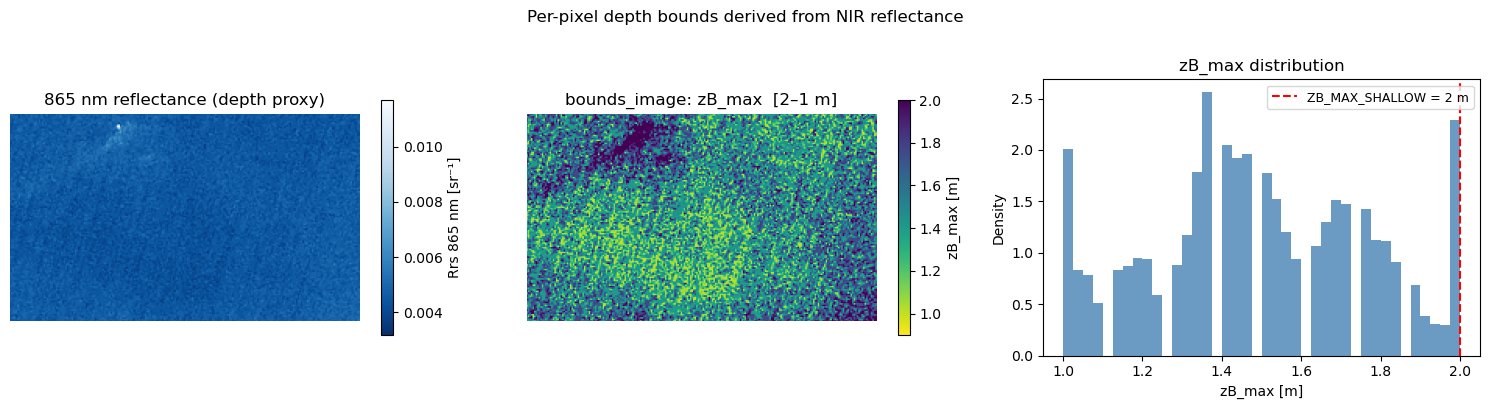

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(R_nir, cmap='Blues_r', origin='upper')
plt.colorbar(im0, ax=axes[0], shrink=0.85, label='Rrs 865 nm [sr\u207b\u00b9]')
axes[0].set_title('865 nm reflectance (depth proxy)')
axes[0].axis('off')

im1 = axes[1].imshow(zB_max_image, cmap='viridis_r', origin='upper',
                     vmin=ZB_MAX_SHALLOW, vmax=ZB_MAX_GLOBAL)
plt.colorbar(im1, ax=axes[1], shrink=0.85, label='zB_max [m]')
axes[1].set_title(f'bounds_image: zB_max  [{ZB_MAX_SHALLOW:.0f}\u2013{ZB_MAX_GLOBAL:.0f} m]')
axes[1].axis('off')

zb_v = zB_max_image[np.isfinite(zB_max_image)]
axes[2].hist(zb_v, bins=40, color='steelblue', alpha=0.8, density=True)
axes[2].axvline(ZB_MAX_SHALLOW, color='r', ls='--', lw=1.5,
                label=f'ZB_MAX_SHALLOW = {ZB_MAX_SHALLOW:.0f} m')
axes[2].set_xlabel('zB_max [m]')
axes[2].set_ylabel('Density')
axes[2].set_title('zB_max distribution')
axes[2].legend(fontsize=9)

plt.suptitle('Per-pixel depth bounds derived from NIR reflectance', y=1.01)
plt.tight_layout()
plt.show()

## 6  Baseline inversion — global bounds

Standard lmfit superpixel inversion using only the global parameter bounds
baked into the `Parameters` object (no `bounds_image`).

In [9]:
t0 = time.perf_counter()
res_base = superpixel_engine.invert_image_superpixel(
    Rrs_image, setup, NOISE,
    invert_fn=lmfit_engine.invert_image,
    n_segments=N_SEGMENTS,
    compactness=COMPACTNESS,
    sigma=SLIC_SIGMA,
    k=K,
    n_components=N_COMPONENTS,
    store_sp_results=True,
    store_chi2_spectral=True,
)
t_base = time.perf_counter() - t0

fit_names = res_base['fit_names']
i_zB  = fit_names.index('zB')
i_fm  = fit_names.index('f_mix_0')
w     = np.isfinite(Rrs_image).all(axis=-1)

print(f'Baseline done in {t_base:.1f} s')
print(f'converged: {res_base["success"][w].sum()} / {w.sum()} '
      f'water pixels ({100*res_base["success"][w].mean():.1f}%)')

Baseline done in 77.0 s
converged: 119613 / 119883 water pixels (99.8%)


## 7  Inversion with `bounds_image`

`bounds_image` is the only difference from the baseline call.  `superpixel_engine`
aggregates the pixel-level bound arrays to per-superpixel bounds using **union
semantics** (nanmin for the min-side, nanmax for the max-side), ensuring the
superpixel's search range is never tighter than any constituent pixel's bound.
The aggregated bounds are then forwarded to `lmfit_engine.invert_image`.

In [10]:
t0 = time.perf_counter()
res_bi = superpixel_engine.invert_image_superpixel(
    Rrs_image, setup, NOISE,
    invert_fn=lmfit_engine.invert_image,
    n_segments=N_SEGMENTS,
    compactness=COMPACTNESS,
    sigma=SLIC_SIGMA,
    k=K,
    n_components=N_COMPONENTS,
    store_sp_results=True,
    store_chi2_spectral=True,
    bounds_image=bounds_image,    # <-- only difference from baseline
)
t_bi = time.perf_counter() - t0

print(f'bounds_image run done in {t_bi:.1f} s')
print(f'converged: {res_bi["success"][w].sum()} / {w.sum()} '
      f'water pixels ({100*res_bi["success"][w].mean():.1f}%)')

bounds_image run done in 96.7 s
converged: 119182 / 119883 water pixels (99.4%)


## 8  Results comparison

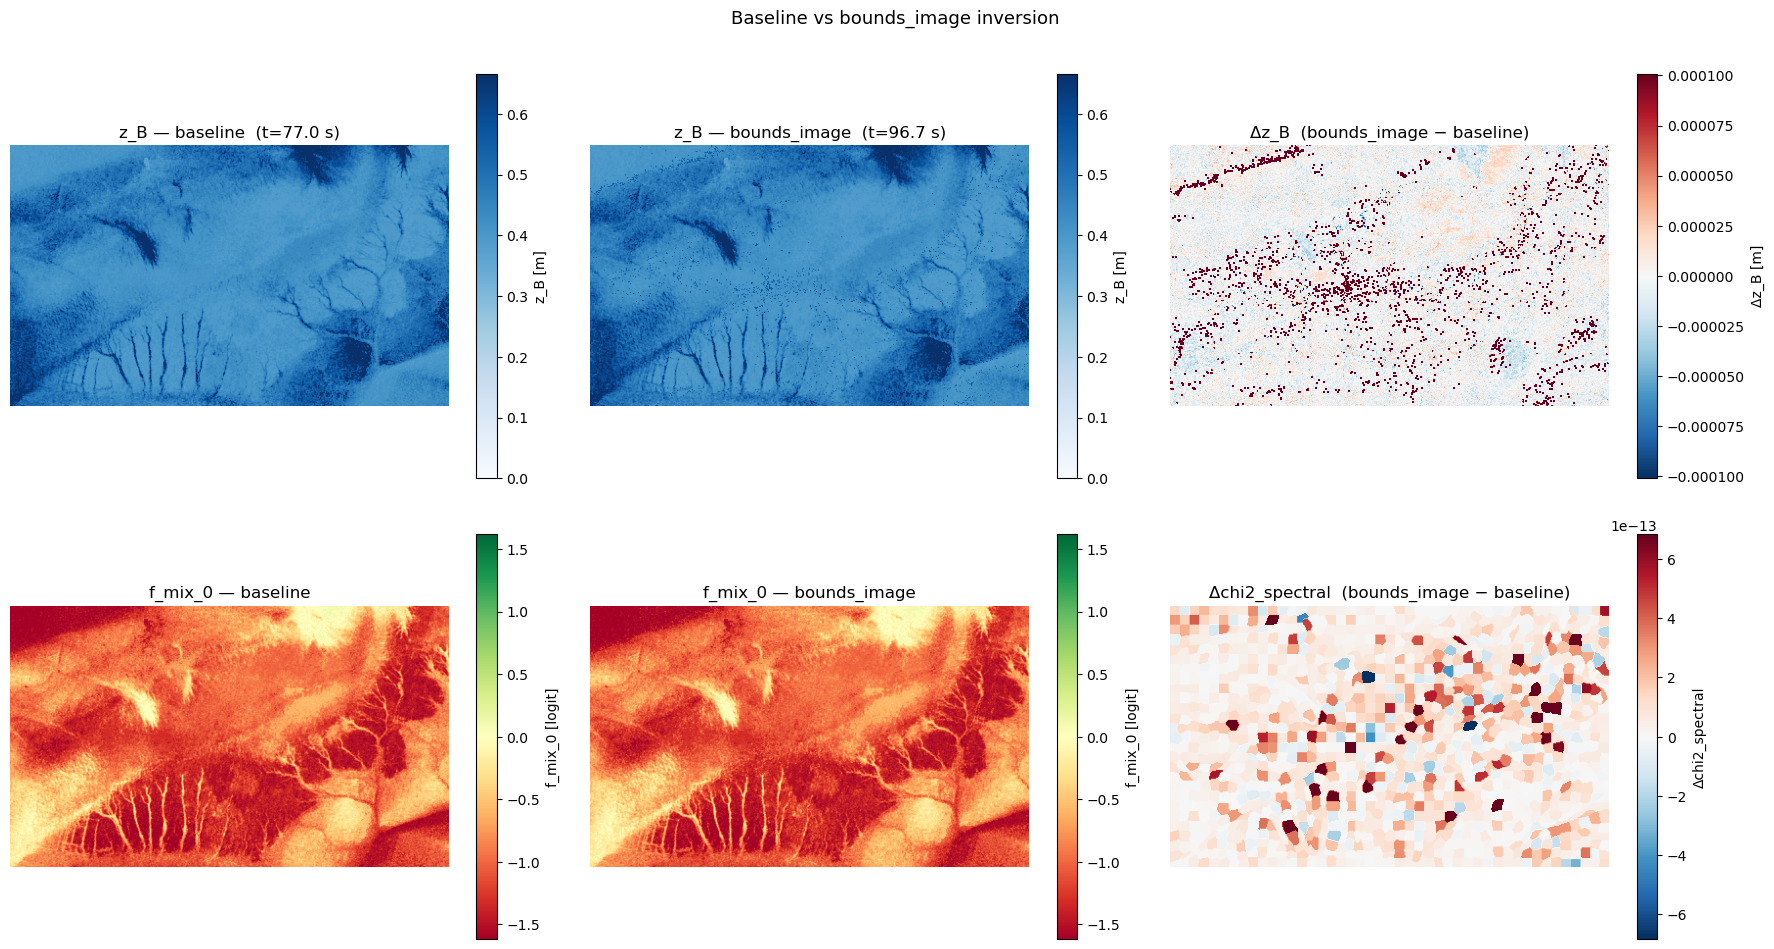

In [11]:
zB_base = res_base['x_hat'][..., i_zB]
zB_bi   = res_bi['x_hat'][..., i_zB]
fm_base = res_base['x_hat'][..., i_fm]
fm_bi   = res_bi['x_hat'][..., i_fm]
zB_diff = zB_bi - zB_base

zB_vmax = np.nanpercentile(np.concatenate([zB_base.ravel(), zB_bi.ravel()]), 98)
fm_vabs = np.nanpercentile(np.abs(np.concatenate([fm_base.ravel(), fm_bi.ravel()])), 98)
d_zB    = np.nanpercentile(np.abs(zB_diff.ravel()), 98)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

im0 = axes[0, 0].imshow(zB_base, cmap='Blues', origin='upper', vmin=0, vmax=zB_vmax)
plt.colorbar(im0, ax=axes[0, 0], shrink=0.85, label='z_B [m]')
axes[0, 0].set_title(f'z_B \u2014 baseline  (t={t_base:.1f} s)')
axes[0, 0].axis('off')

im1 = axes[0, 1].imshow(zB_bi, cmap='Blues', origin='upper', vmin=0, vmax=zB_vmax)
plt.colorbar(im1, ax=axes[0, 1], shrink=0.85, label='z_B [m]')
axes[0, 1].set_title(f'z_B \u2014 bounds_image  (t={t_bi:.1f} s)')
axes[0, 1].axis('off')

im2 = axes[0, 2].imshow(zB_diff, cmap='RdBu_r', origin='upper', vmin=-d_zB, vmax=d_zB)
plt.colorbar(im2, ax=axes[0, 2], shrink=0.85, label='\u0394z_B [m]')
axes[0, 2].set_title('\u0394z_B  (bounds_image \u2212 baseline)')
axes[0, 2].axis('off')

im3 = axes[1, 0].imshow(fm_base, cmap='RdYlGn', origin='upper',
                         vmin=-fm_vabs, vmax=fm_vabs)
plt.colorbar(im3, ax=axes[1, 0], shrink=0.85, label='f_mix_0 [logit]')
axes[1, 0].set_title('f_mix_0 \u2014 baseline')
axes[1, 0].axis('off')

im4 = axes[1, 1].imshow(fm_bi, cmap='RdYlGn', origin='upper',
                         vmin=-fm_vabs, vmax=fm_vabs)
plt.colorbar(im4, ax=axes[1, 1], shrink=0.85, label='f_mix_0 [logit]')
axes[1, 1].set_title('f_mix_0 \u2014 bounds_image')
axes[1, 1].axis('off')

chi2_d = res_bi['chi2_spectral'] - res_base['chi2_spectral']
cd_abs = np.nanpercentile(np.abs(chi2_d.ravel()), 98)
im5 = axes[1, 2].imshow(chi2_d, cmap='RdBu_r', origin='upper',
                         vmin=-cd_abs, vmax=cd_abs)
plt.colorbar(im5, ax=axes[1, 2], shrink=0.85, label='\u0394chi2_spectral')
axes[1, 2].set_title('\u0394chi2_spectral  (bounds_image \u2212 baseline)')
axes[1, 2].axis('off')

plt.suptitle('Baseline vs bounds_image inversion', fontsize=13)
plt.tight_layout()
plt.show()

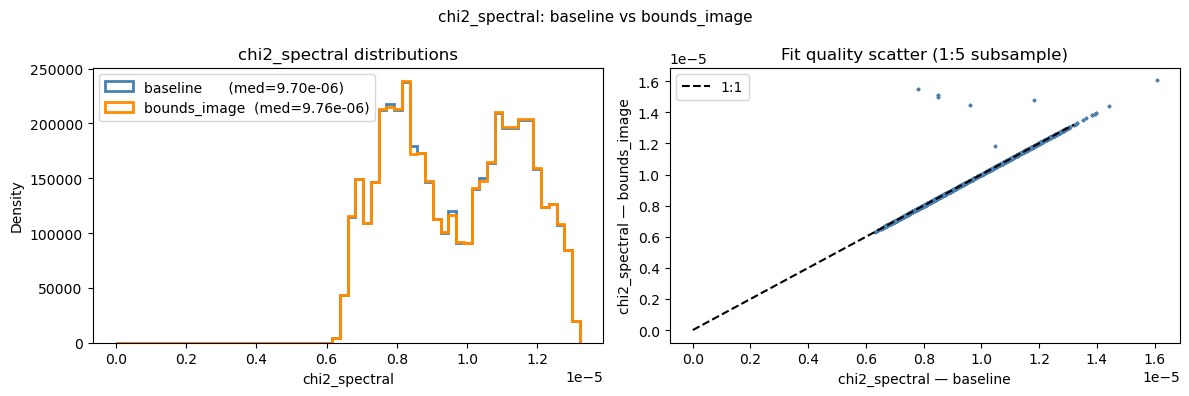

In [12]:
chi2_b_all = res_base['chi2_spectral'].ravel()
chi2_i_all = res_bi['chi2_spectral'].ravel()
both_valid = np.isfinite(chi2_b_all) & np.isfinite(chi2_i_all)
chi2_b_v   = chi2_b_all[both_valid]
chi2_i_v   = chi2_i_all[both_valid]
vmax_h     = np.nanpercentile(np.concatenate([chi2_b_v, chi2_i_v]), 99)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chi2_b_v, bins=60, range=(0, vmax_h), density=True,
             histtype='step', color='steelblue', lw=2,
             label=f'baseline      (med={np.nanmedian(chi2_b_v):.2e})')
axes[0].hist(chi2_i_v, bins=60, range=(0, vmax_h), density=True,
             histtype='step', color='darkorange', lw=2,
             label=f'bounds_image  (med={np.nanmedian(chi2_i_v):.2e})')
axes[0].set_xlabel('chi2_spectral')
axes[0].set_ylabel('Density')
axes[0].set_title('chi2_spectral distributions')
axes[0].legend()

axes[1].scatter(chi2_b_v[::5], chi2_i_v[::5], s=2, alpha=0.3, color='steelblue')
lim = np.nanpercentile(np.concatenate([chi2_b_v, chi2_i_v]), 99)
axes[1].plot([0, lim], [0, lim], 'k--', lw=1.5, label='1:1')
axes[1].set_xlabel('chi2_spectral \u2014 baseline')
axes[1].set_ylabel('chi2_spectral \u2014 bounds_image')
axes[1].set_title('Fit quality scatter (1:5 subsample)')
axes[1].legend()

plt.suptitle('chi2_spectral: baseline vs bounds_image', fontsize=11)
plt.tight_layout()
plt.show()

## 9  Spot-check — superpixels most affected by `bounds_image`

Show the 3 superpixels with the largest change in retrieved `z_B`.  These are
typically shallow pixels where the NIR proxy was most constraining.  Plotting both
fits alongside the observed spectrum reveals which retrieval is better supported
by the data (lower chi2_spectral).

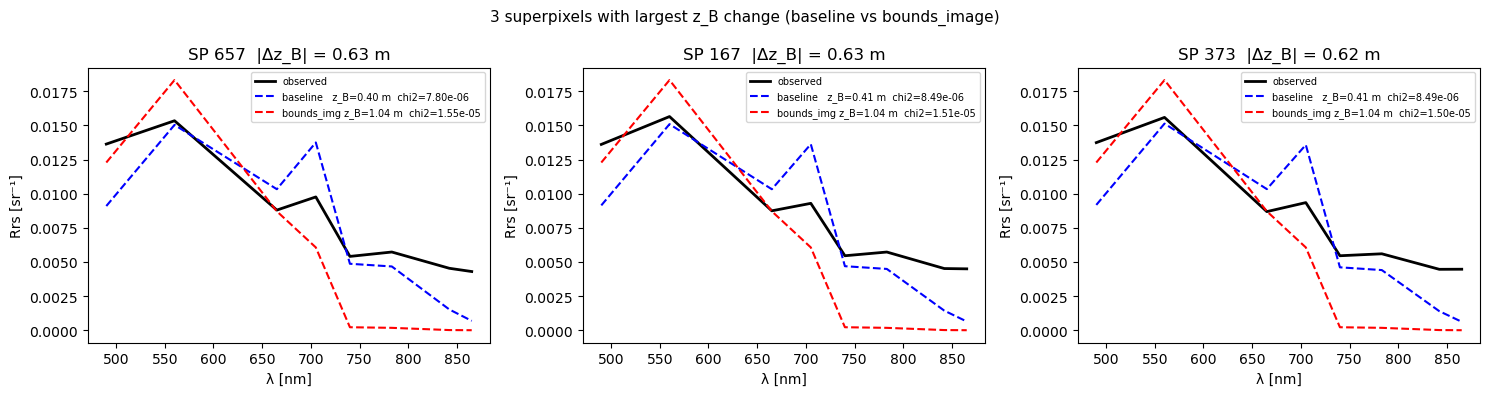

In [13]:
labels    = res_base['labels']
sp_obs, _ = superpixel_engine.aggregate_superpixels(Rrs_image, labels)

sp_zB_base = res_base['sp_results']['x_hat'][:, i_zB]
sp_zB_bi   = res_bi['sp_results']['x_hat'][:, i_zB]
zB_delta   = np.abs(sp_zB_bi - sp_zB_base)

valid_sp  = np.isfinite(sp_zB_base) & np.isfinite(sp_obs).all(axis=-1)
valid_idx = np.where(valid_sp)[0]
top3_idx  = valid_idx[np.argsort(zB_delta[valid_idx])[-3:]][::-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, sp_idx in zip(axes, top3_idx):
    obs = sp_obs[sp_idx]

    p_b = params.copy()
    p_i = params.copy()
    for j, name in enumerate(fit_names):
        p_b[name].value = res_base['sp_results']['x_hat'][sp_idx, j]
        p_i[name].value = res_bi['sp_results']['x_hat'][sp_idx, j]
    fit_b = forward_func(p_b, wavelengths)
    fit_i = forward_func(p_i, wavelengths)

    chi2_b = float(res_base['sp_results']['chi2_spectral'][sp_idx])
    chi2_i = float(res_bi['sp_results']['chi2_spectral'][sp_idx])

    ax.plot(wavelengths, obs,   'k-',  lw=2,   label='observed')
    ax.plot(wavelengths, fit_b, 'b--', lw=1.5,
            label=f'baseline   z_B={sp_zB_base[sp_idx]:.2f} m  chi2={chi2_b:.2e}')
    ax.plot(wavelengths, fit_i, 'r--', lw=1.5,
            label=f'bounds_img z_B={sp_zB_bi[sp_idx]:.2f} m  chi2={chi2_i:.2e}')
    ax.set_title(f'SP {sp_idx}  |\u0394z_B| = {zB_delta[sp_idx]:.2f} m')
    ax.set_xlabel('\u03bb [nm]')
    ax.set_ylabel('Rrs [sr\u207b\u00b9]')
    ax.legend(fontsize=7)

plt.suptitle('3 superpixels with largest z_B change (baseline vs bounds_image)', fontsize=11)
plt.tight_layout()
plt.show()